# Import libraries

In [1]:
# !pip install stargazer
# !pip install altair
# !pip install statsmodels

In [2]:
import pandas as pd
import numpy as np
import requests
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
import json
apikey = 'AU24y7aNaHPclqjxNcZkTA4q9HcNsVla2ILFhE7h'
import tqdm
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import datetime
import altair as alt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.compat import lzip
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import datasets

# Data extract

In [3]:
##https://policeviolencereport.org/##
##4 tabs##
policeViolence = pd.read_excel('MPVDatasetDownload.xlsx',sheet_name='2013-2020 Police Killings', engine='openpyxl')
censusData = pd.read_csv('sub-est2019_all.csv',encoding='ISO-8859-1')
censusData = censusData[censusData['SUMLEV'].isin([162])] #unsure about inclusion of 71 as well
censusData['NAME']=censusData['NAME'].apply(lambda text: text.rsplit(' ', 1)[0])
states = pd.read_csv('states.csv')
policeViolence = policeViolence.merge(states,left_on='State',right_on='Code',how='left')
policeViolence = policeViolence.merge(censusData,left_on=['City','Description'],right_on=['NAME','STNAME'],how='left')
policeViolence = policeViolence.dropna(subset=['City'])
policeViolence['Year'] = pd.DatetimeIndex(policeViolence['Date of Incident (month/day/year)']).year
policeViolence['period']=0

In [4]:
# cityPops = pd.pivot_table(policeViolence, values='POPESTIMATE2019', index=['City','State']).reset_index().ffill()
# cityPops['City'].sample(n=200, random_state=42)

In [5]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 100)
dallas = policeViolence[policeViolence['City']=='Dallas'] #CIT last updated = 2014-04-15 20:51:06 #RIGHT start date 2018
dallas = dallas[dallas['State'].isin(['TX'])]

In [6]:
# policeViolence['Criminal Charges?'].unique()
# policeViolence['Armed/Unarmed Status'].unique()
# policeViolence[policeViolence['City'].str.contains('San')]
# policeViolence[policeViolence['City']=='San Jose']

In [7]:
CIT = pd.read_csv('fatalities.csv')
CIT['City']=CIT['City'].apply(lambda text: text.rsplit('[', 1)[0])
CIT

,2020\nrank,City,State[c],2020\ncensus,2010\ncensus,Change,2016 land area,Unnamed: 7,2016 population density,Unnamed: 9,Location,CIT program,Start,Source,Other programs,Unnamed: 15
0,1,New York,New York,"8,804,190","8,175,133",0.0769,301.5 sq mi,780.9 km2,"28,317/sq mi","10,933/km2",40.66°N 73.93°W,TRUE,2015,https://www1.nyc.gov/assets/doi/reports/pdf/20...,NaN,NaN
1,2,Los Angeles,California,"3,898,747","3,792,621",0.028,468.7 sq mi,"1,213.9 km2","8,484/sq mi","3,276/km2",34.01°N 118.41°W,NaN,2003,NaN,NaN,NaN
2,3,Chicago,Illinois,"2,746,388","2,695,598",0.0188,227.3 sq mi,588.7 km2,"11,900/sq mi","4,600/km2",41.83°N 87.68°W,NaN,2004,NaN,NaN,NaN
3,4,Houston,Texas,"2,304,580","2,100,263",0.0973,637.5 sq mi,"1,651.1 km2","3,613/sq mi","1,395/km2",29.78°N 95.39°W,NaN,1999,NaN,NaN,NaN
4,5,Phoenix,Arizona,"1,608,139","1,445,632",0.1124,517.6 sq mi,"1,340.6 km2","3,120/sq mi","1,200/km2",33.57°N 112.09°W,NaN,2000,NaN,NaN,NaN
5,6,Philadelphia,Pennsylvania,"1,603,797","1,526,006",0.051,134.2 sq mi,347.6 km2,"11,683/sq mi","4,511/km2",40.00°N 75.13°W,NaN,2007,NaN,NaN,NaN
6,7,San Antonio,Texas,"1,434,625","1,327,407",0.0808,461.0 sq mi,"1,194.0 km2","3,238/sq mi","1,250/km2",29.47°N 98.52°W,NaN,2005,NaN,NaN,NaN
7,8,San Diego,California,"1,386,932","1,307,402",0.0608,325.2 sq mi,842.3 km2,"4,325/sq mi","1,670/km2",32.81°N 117.13°W,NaN,1996,NaN,NaN,NaN
8,9,Dallas,Texas,"1,304,379","1,197,816",0.089,340.9 sq mi,882.9 km2,"3,866/sq mi","1,493/km2",32.79°N 96.76°W,NaN,NaN,NaN,NaN,NaN
9,10,San Jose,California,"1,013,240","945,942",0.0711,177.5 sq mi,459.7 km2,"5,777/sq mi","2,231/km2",37.29°N 121.81°W,TRUE,2018,https://sanjosespotlight.com/sanchez-krey-and-...,NaN,NaN


In [8]:
cities = list(CIT['City'].unique())

In [9]:
#https://www.qualtrics.com/experience-management/research/determine-sample-size/
policeViolence[policeViolence['Year'].isin([2013,2014,2015,2016,2017,2018])].shape[0]

6538

In [10]:
PVs = []
CITs = []
for city in cities:
    try:
        CITstart = int(CIT[CIT['City']==city]['Start'].values[0])
        preCIT = [CITstart-2,CITstart-1]
        CITactive = [CITstart,CITstart+1]
        if preCIT[0] in [2013,2014,2015,2016,2017,2018]:
            PVslice = policeViolence[policeViolence['City']==city]
            PVyearOne = PVslice[PVslice['Year']==preCIT[0]].copy()
            PVyearOne.loc[:,'period'].replace(0,1,inplace=True)
            PVyearTwo = PVslice[PVslice['Year']==preCIT[1]].copy()
            PVyearTwo.loc[:,'period'].replace(0,2,inplace=True)
            PVyearThree = PVslice[PVslice['Year']==CITactive[0]].copy()
            PVyearThree.loc[:,'period'].replace(0,3,inplace=True)
            PVyearFour = PVslice[PVslice['Year']==CITactive[1]].copy()
            PVyearFour.loc[:,'period'].replace(0,4,inplace=True)
            PV = pd.concat([PVyearOne,PVyearTwo,PVyearThree,PVyearFour])
            PVs.append(PV)
        else:
            continue   
    except:
        continue
PVsample = pd.concat(PVs)
PVsample.shape[0]

356

In [11]:
PVsample

,Victim's name,Victim's age,Victim's gender,Victim's race,URL of image of victim,Date of Incident (month/day/year),Street Address of Incident,City,State,Zipcode,County,Agency responsible for death,ORI Agency Identifier (if available),Cause of death,A brief description of the circumstances surrounding the death,Official disposition of death (justified or other),Criminal Charges?,Link to news article or photo of official document,Symptoms of mental illness?,Armed/Unarmed Status,Alleged Weapon (Source: WaPo and Review of Cases Not Included in WaPo Database),Alleged Threat Level (Source: WaPo),Fleeing (Source: WaPo),Body Camera (Source: WaPo),WaPo ID (If included in WaPo database),Off-Duty Killing?,Geography (via Trulia methodology based on zipcode population density: http://jedkolko.com/wp-content/uploads/2015/05/full-ZCTA-urban-suburban-rural-classification.xlsx ),MPV ID,Fatal Encounters ID,Encounter Type (DRAFT),Initial Reported Reason for Encounter (DRAFT),Names of Officers Involved (DRAFT),Race of Officers Involved (DRAFT),Known Past Shootings of Officer(s) (DRAFT),Call for Service? (DRAFT),Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Code,Description,SUMLEV,STATE,COUNTY,PLACE,COUSUB,CONCIT,PRIMGEO_FLAG,FUNCSTAT,NAME,STNAME,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015,POPESTIMATE2016,POPESTIMATE2017,POPESTIMATE2018,POPESTIMATE2019,Year,period
8458,Rexford Dasrath,22,Male,Black,http://static.wixstatic.com/media/f8a96d_5432b...,2013-11-18,900 Hart St.,New York,NY,11237.0,Kings,New York Police Department,NY0303000,Gunshot,NYPD were called when a man wielding a knife t...,Unknown,No known charges,http://www.nydailynews.com/new-york/nyc-crime/...,Yes,Allegedly Armed,knife,NaN,NaN,NaN,NaN,NaN,Urban,983.0,13711.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NY,New York,162.0,36.0,0.0,51000.0,0.0,0.0,0.0,A,New York,New York,8175133,8175031.0,8190209.0,8272948.0,8346693.0,8396091.0,8433806.0,8463049.0,8469153.0,8437478.0,8390081.0,8336817.0,2013,1
8911,Thomas Robinson,50,Male,Unknown race,NaN,2013-06-18,Dumont Ave & Hinsdale St,New York,NY,11207.0,New York,New York Police Department,NY0303000,Gunshot,Police interrupted a mugging. The suspect shot...,Unknown,No known charges,http://www.newsday.com/news/nypd-suspect-dead-...,No,Allegedly Armed,gun,NaN,NaN,NaN,NaN,NaN,Urban,528.0,12978.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NY,New York,162.0,36.0,0.0,51000.0,0.0,0.0,0.0,A,New York,New York,8175133,8175031.0,8190209.0,8272948.0,8346693.0,8396091.0,8433806.0,8463049.0,8469153.0,8437478.0,8390081.0,8336817.0,2013,1
9015,Jackson Alexandre,28,Male,Unknown race,NaN,2013-05-23,541 Court St,New York,NY,11231.0,Kings,New York Police Department,NY0303000,Gunshot,"A ""crazed"" Alexandre stabbed his roommate whil...",Unreported,No known charges,http://www.nydailynews.com/new-york/brooklyn/c...,Yes,Allegedly Armed,knife,NaN,NaN,NaN,NaN,NaN,Urban,426.0,12835.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NY,New York,162.0,36.0,0.0,51000.0,0.0,0.0,0.0,A,New York,New York,8175133,8175031.0,8190209.0,8272948.0,8346693.0,8396091.0,8433806.0,8463049.0,8469153.0,8437478.0,8390081.0,8336817.0,2013,1
9073,Deion Fludd,17,Male,Black,http://i.dailymail.co.uk/i/pix/2014/04/11/arti...,2013-05-05,Rockaway Avenue and Fulton Street,New York,NY,11233.0,Kings,New York Police Department,NY0303000,Beaten,Fludd was chased and arrested for jumping a su...,Unreported,No known charges,http://www.dailymail.co.uk/news/article-260279...,No,Unarmed/Did Not Have Actual Weapon,no object,NaN,NaN,NaN,NaN,NaN,Urban,366.0,12749.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NY,New York,162.0,36.0,0.0,51000.0,0.0,0.0,0.0,A,New York,New Yo

In [12]:
print('Started csv load @ ' + str(datetime.datetime.now()))

wash19incidents = pd.read_csv('washington/NIBRS_incident.csv')
wash19incidents['INCIDENT_MONTH'] = pd.DatetimeIndex(wash19incidents['INCIDENT_DATE']).month
wash19arrestees = pd.read_csv('washington/NIBRS_ARRESTEE.csv')
wash19offenseTypes = pd.read_csv('washington/NIBRS_OFFENSE_TYPE.csv')
relevant_offenses = ['Trespass of Real Property','Curfew/Loitering/Vagrancy Violations','Drug/Narcotic Violations','Drug Equipment Violations','Drunkenness','Disorderly Conduct','Family Offenses, Nonviolent']
wash19agencies = pd.read_csv('washington/agencies.csv')
wash19race = pd.read_csv('washington/REF_RACE.csv')
wash19justForce = pd.read_csv('washington/NIBRS_JUSTIFIABLE_FORCE.csv')
wash19victim = pd.read_csv('washington/NIBRS_VICTIM.csv')
wash19victimCirc = pd.read_csv('washington/NIBRS_VICTIM_CIRCUMSTANCES.csv')
wash19victimInj= pd.read_csv('washington/NIBRS_VICTIM_INJURY.csv')
wash19victimOffense = pd.read_csv('washington/NIBRS_VICTIM_OFFENSE.csv')
wash19victimType = pd.read_csv('washington/NIBRS_VICTIM_TYPE.csv')
wash19circCodes = pd.read_csv('washington/NIBRS_CIRCUMSTANCES.csv')
wash19injCodes = pd.read_csv('washington/NIBRS_INJURY.csv')

wash18incidents = pd.read_csv('washington/2018/NIBRS_incident.csv')
wash18incidents['INCIDENT_MONTH'] = pd.DatetimeIndex(wash18incidents['INCIDENT_DATE']).month
wash18arrestees = pd.read_csv('washington/2018/NIBRS_ARRESTEE.csv')
wash18offenseTypes = pd.read_csv('washington/2018/NIBRS_OFFENSE_TYPE.csv')
wash18agencies = pd.read_csv('washington/2018/agencies.csv')
wash18race = pd.read_csv('washington/2018/REF_RACE.csv')
wash18justForce = pd.read_csv('washington/2018/NIBRS_JUSTIFIABLE_FORCE.csv')
wash18victim = pd.read_csv('washington/2018/NIBRS_VICTIM.csv')
wash18victimCirc = pd.read_csv('washington/2018/NIBRS_VICTIM_CIRCUMSTANCES.csv')
wash18victimInj= pd.read_csv('washington/2018/NIBRS_VICTIM_INJURY.csv')
wash18victimOffense = pd.read_csv('washington/2018/NIBRS_VICTIM_OFFENSE.csv')
wash18victimType = pd.read_csv('washington/2018/NIBRS_VICTIM_TYPE.csv')
wash18circCodes = pd.read_csv('washington/2018/NIBRS_CIRCUMSTANCES.csv')
wash18injCodes = pd.read_csv('washington/NIBRS_INJURY.csv')

print('Finished csv load @ ' + str(datetime.datetime.now()))

Started csv load @ 2021-09-13 01:15:26.633249
Finished csv load @ 2021-09-13 01:16:24.840472


In [13]:
# display(wash19victimOffense)

In [14]:
wash19victim = wash19victim.merge(wash19victimCirc, how='left', on='VICTIM_ID')
wash19victim = wash19victim.merge(wash19circCodes, how='left', on='CIRCUMSTANCES_ID')
wash19victim = wash19victim.merge(wash19victimInj, how='left', on='VICTIM_ID')
wash19victim = wash19victim.merge(wash19victimType, how='left', on='VICTIM_TYPE_ID')
wash19victim = wash19victim.merge(wash19injCodes, how='left', on='INJURY_ID')
wash19victim = wash19victim.merge(wash19justForce, how='left', on='JUSTIFIABLE_FORCE_ID')
# wash19victim

In [15]:
wash18victim = wash18victim.merge(wash18victimCirc, how='left', on='VICTIM_ID')
wash18victim = wash18victim.merge(wash18circCodes, how='left', on='CIRCUMSTANCES_ID')
wash18victim = wash18victim.merge(wash18victimInj, how='left', on='VICTIM_ID')
wash18victim = wash18victim.merge(wash18victimType, how='left', on='VICTIM_TYPE_ID')
wash18victim = wash18victim.merge(wash18injCodes, how='left', on='INJURY_ID')
wash18victim = wash18victim.merge(wash18justForce, how='left', on='JUSTIFIABLE_FORCE_ID')
# wash18victim

In [16]:
print('Started merge @ ' + str(datetime.datetime.now()))

wash19offenses = pd.read_csv('washington/NIBRS_OFFENSE.csv')
wash19offenses = wash19offenses.merge(wash19incidents, how='left', on='INCIDENT_ID')
wash19offenses = wash19offenses.merge(wash19agencies, how='left', on='AGENCY_ID')
wash19offenses = wash19offenses.merge(wash19offenseTypes, how='left', on='OFFENSE_TYPE_ID')
wash19offenses = wash19offenses.merge(wash19arrestees, how='left', on='INCIDENT_ID')
wash19offenses = wash19offenses.merge(wash19race, how='left', on='RACE_ID')
wash19location = pd.read_csv('washington/NIBRS_LOCATION_TYPE.csv')
wash19offenses = wash19offenses.merge(wash19location, how='left', on='LOCATION_ID')
wash19offenses = wash19offenses.merge(wash19victim, how='left', on='INCIDENT_ID')


wash18offenses = pd.read_csv('washington/2018/NIBRS_OFFENSE.csv')
wash18offenses = wash18offenses.merge(wash18incidents, how='left', on='INCIDENT_ID')
wash18offenses = wash18offenses.merge(wash18agencies, how='left', on='AGENCY_ID')
wash18offenses = wash18offenses.merge(wash18offenseTypes, how='left', on='OFFENSE_TYPE_ID')
wash18offenses = wash18offenses.merge(wash18arrestees, how='left', on='INCIDENT_ID')
wash18offenses = wash18offenses.merge(wash18race, how='left', on='RACE_ID')
wash18location = pd.read_csv('washington/2018/NIBRS_LOCATION_TYPE.csv')
wash18offenses = wash18offenses.merge(wash18location, how='left', on='LOCATION_ID')
wash18offenses = wash18offenses.merge(wash18victim, how='left', on='INCIDENT_ID')

print('Finished merge @ ' + str(datetime.datetime.now()))

Started merge @ 2021-09-13 01:16:27.077218
Finished merge @ 2021-09-13 01:17:36.161814


In [17]:
#need to figure out which columns were added to arrestees dataframe and drop those from 18/19
wash1819offenses = pd.concat([wash19offenses,wash18offenses])
# wash1819offenses

In [18]:
olympia19offenses = wash19offenses[wash19offenses['COUNTY_NAME']=='THURSTON']
olympia19offenseCounts = pd.DataFrame(olympia19offenses.groupby(['INCIDENT_MONTH','OFFENSE_NAME'])['OFFENSE_NAME'].count())
olympia19offenseCounts = olympia19offenseCounts.rename(columns={'OFFENSE_NAME':'OFFENSE_COUNT'})
olympia19offenseCounts = olympia19offenseCounts.reset_index()
olympia19offenseCounts['CRU'] = np.where(olympia19offenseCounts['INCIDENT_MONTH']<4,0,1)
relevant_offenses = ['Trespass of Real Property','Curfew/Loitering/Vagrancy Violations','Drug/Narcotic Violations','Drug Equipment Violations','Drunkenness','Disorderly Conduct','Family Offenses, Nonviolent']
olympia19offenseCounts = olympia19offenseCounts[olympia19offenseCounts['OFFENSE_NAME'].isin(relevant_offenses)]
# olympia19offenseCounts = olympia19offenseCounts[olympia19offenseCounts['OFFENSE_NAME']=='Drug/Narcotic Violations']
# olympia19offenseCounts['Rolling'] = olympia19offenseCounts['OFFENSE_COUNT'].rolling(8).mean()

olympia1819offenses = wash1819offenses[wash1819offenses['COUNTY_NAME']=='THURSTON']
olympia1819offenses['INCIDENT_YEAR'] = pd.DatetimeIndex(olympia1819offenses['INCIDENT_DATE']).year
olympia1819offenseCounts = pd.DataFrame(olympia1819offenses.groupby(['INCIDENT_YEAR','INCIDENT_MONTH','OFFENSE_NAME'])['OFFENSE_NAME'].count())
pd.set_option('display.max_rows', 500)
olympia1819offenseCounts = olympia1819offenseCounts.rename(columns={'OFFENSE_NAME':'OFFENSE_COUNT'})
olympia1819offenseCounts = olympia1819offenseCounts.reset_index()
olympia1819offenseCounts['CRU'] = np.where((olympia1819offenseCounts['INCIDENT_MONTH']<4)|(olympia1819offenseCounts['INCIDENT_YEAR']==2018),0,1)
relevant_offenses = ['Trespass of Real Property','Curfew/Loitering/Vagrancy Violations','Drug/Narcotic Violations','Drug Equipment Violations','Drunkenness','Disorderly Conduct','Family Offenses, Nonviolent']
# olympia1819offenseCounts = olympia1819offenseCounts[olympia1819offenseCounts['OFFENSE_NAME'].isin(relevant_offenses)]
olympia1819offenseCounts = olympia1819offenseCounts[olympia1819offenseCounts['OFFENSE_NAME']=='Drug/Narcotic Violations']
# olympia19offenseCounts['Rolling'] = olympia19offenseCounts['OFFENSE_COUNT'].rolling(8).mean()

/opt/oss/conda3/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


In [19]:
olympia19chart = alt.Chart(olympia19offenseCounts).mark_line().encode(
    x='INCIDENT_MONTH:O',
    y='OFFENSE_COUNT',
    color='OFFENSE_NAME'
)

In [20]:
olympia1819chart = alt.Chart(olympia1819offenseCounts,width=800, height=200).mark_line().encode(
    x='INCIDENT_MONTH:O',
    y='OFFENSE_COUNT',
    color=alt.Color('INCIDENT_YEAR:O',scale=alt.Scale(range=['#D15B41','#4B3D3D']))
)
display(olympia1819chart)
# olympia1819offenseCounts

alt.Chart(...)

In [21]:
olympia1819offenses = wash1819offenses[wash1819offenses['COUNTY_NAME']=='THURSTON']
olympia1819offenses['INCIDENT_YEAR'] = pd.DatetimeIndex(olympia1819offenses['INCIDENT_DATE']).year
#FILTER OUT INJURIES WE ARENT CONCERNED WITH
olympia1819injuryCounts = pd.DataFrame(olympia1819offenses.groupby(['INCIDENT_YEAR','INCIDENT_MONTH'])['INJURY_NAME'].count())
olympia1819injuryCounts = olympia1819injuryCounts.rename(columns={'INJURY_NAME':'INJURY_COUNT'})
olympia1819injuryCounts = olympia1819injuryCounts.reset_index()
olympia1819injuryCounts['CRU'] = np.where((olympia1819injuryCounts['INCIDENT_MONTH']<4)|(olympia1819injuryCounts['INCIDENT_YEAR']==2018),0,1)
olympia1819injuryCounts

/opt/oss/conda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,INCIDENT_YEAR,INCIDENT_MONTH,INJURY_COUNT,CRU
0,2018,1,269,0
1,2018,2,255,0
2,2018,3,237,0
3,2018,4,262,0
4,2018,5,287,0
5,2018,6,265,0
6,2018,7,272,0
7,2018,8,242,0
8,2018,9,254,0
9,2018,10,249,0


In [22]:
olympia1819chart = alt.Chart(olympia1819injuryCounts,width=800, height=200).mark_line().encode(
    x='INCIDENT_MONTH:O',
    y='INJURY_COUNT',
    color=alt.Color('INCIDENT_YEAR:O',scale=alt.Scale(range=['#D15B41','#4B3D3D']))
)
display(olympia1819chart)

alt.Chart(...)

# Supervised models

## KNN classification

### Model development

#### Police violence 

In [23]:
from sklearn.preprocessing import StandardScaler
policeViolence['Year'] = pd.DatetimeIndex(policeViolence['Date of Incident (month/day/year)']).year
policeViolence['Charges'] = np.where(policeViolence['Criminal Charges?'].str.contains('Charged'),1,0)
policeViolence['Armed']= np.where(policeViolence['Armed/Unarmed Status'].str.contains('Unarmed|Unclear'),0,1)
policeViolence['Mental illness'] = np.where(policeViolence['Symptoms of mental illness?'].str.contains('Yes'),1,0)
policeViolenceCounts = pd.DataFrame(policeViolence.groupby(['Year',"Victim's race",'Mental illness','Charges','Armed'])['Cause of death'].count())
policeViolenceCounts = policeViolenceCounts.rename(columns={"Cause of death":'Death_count'})
policeViolenceCounts = policeViolenceCounts.reset_index()
policeViolenceCounts = policeViolenceCounts.rename(columns={"Victim's race":"Race"})
policeViolenceCounts['Black'] = np.where(policeViolenceCounts['Race']=='Black',1,0)
policeViolenceCounts['White'] = np.where(policeViolenceCounts['Race']=='White',1,0)
policeViolenceCounts['Hispanic'] = np.where(policeViolenceCounts['Race']=='Hispanic',1,0)
policeViolenceCounts['Unknown_race'] = np.where(policeViolenceCounts['Race']=='Unknown race',1,0)

feature_names = ['Year', 'Mental illness', 'Charges', 'Armed', 'Death_count','Black','White','Hispanic','Unknown_race'] #add in population
x_vals = ['Year', 'Charges', 'Armed', 'Death_count','Black','White','Hispanic','Unknown_race']

feature_names = ['Year', 'Mental illness', 'Charges', 'Armed','Black'] #add in population
x_vals = ['Year', 'Charges', 'Armed', 'Black']

In [24]:
#train-test-split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(policeViolenceCounts[x_vals], policeViolenceCounts['Mental illness'], test_size=0.33, random_state=42)

In [25]:
#knn training
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 1)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [26]:
#prediction on mean value
prediction = knn.predict(X_train).reshape(-1,1)
unique, counts = np.unique(prediction, return_counts=True)
avgdata = dict(zip(unique, counts))
values = avgdata.values()
morecommon = max(values)
keys = avgdata.keys()
def get_key(val): 
    for key, value in avgdata.items(): 
         if val == value: 
            return key 
commonkey  = get_key(morecommon)
pred = np.unique(prediction)

filterpred = pred == commonkey
pred = pred[filterpred]
pred

array([0])

In [27]:
#prediction on test set
preds = knn.predict(X_test)

In [28]:
#evaluation on test set
knn = KNeighborsClassifier(n_neighbors = 1)
knn.fit(X_train, y_train)
score = knn.score(X_test, y_test)

In [29]:
score

0.4838709677419355

In [30]:
#model parameter tuning
def optimal_k():
    k_best = None
    
    
    k_range = range(1,21,2)
    scores = []
        
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors = k)
        knn.fit(X_train, y_train)
        scores.append([k,knn.score(X_test, y_test)])
        
    maxscore = 0
    k_best = 0
    
    for score in scores:
        if score[1]>maxscore:
            maxscore = score[1]
            k_best = score[0]
        else:
            next
    
    display(scores)
    
    return k_best

optimal_k()

[[1, 0.4838709677419355],
 [3, 0.5161290322580645],
 [5, 0.44086021505376344],
 [7, 0.44086021505376344],
 [9, 0.4946236559139785],
 [11, 0.4731182795698925],
 [13, 0.5591397849462365],
 [15, 0.5053763440860215],
 [17, 0.4946236559139785],
 [19, 0.5161290322580645]]

13

In [31]:
#testing for overfitting
def overfitting():
    k_best = None    
    training_score = None
    test_score = None
    knn = None
    
#     X_train, X_test, y_train, y_test = train_test_split(policeViolenceCounts[x_vals], policeViolenceCounts['Mental illness'], test_size=0.33, random_state=42)
    
    knn = KNeighborsClassifier(n_neighbors = optimal_k())
    knn.fit(X_train, y_train)
    training_score = knn.score(X_train, y_train)
    test_score = knn.score(X_test, y_test)
    
#     X_train, X_test, y_train, y_test = answer_four()
    
    k_range = range(1,21,2)
    scores = []
        
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors = k)
        knn.fit(X_train, y_train)
        scores.append([k,knn.score(X_train, y_train)])
        
    maxscore = 0
    train_best = 0
    
    for score in scores:
        if score[1]>maxscore:
            maxscore = score[1]
            train_best = score[0]
        else:
            next
    
    knn1 = KNeighborsClassifier(n_neighbors = train_best)
    knn1.fit(X_test, y_test)
    test_score = knn1.score(X_test, y_test)
    
    k_best = (train_best, maxscore, test_score)
    
    return k_best

overfitting()

[[1, 0.4838709677419355],
 [3, 0.5161290322580645],
 [5, 0.44086021505376344],
 [7, 0.44086021505376344],
 [9, 0.4946236559139785],
 [11, 0.4731182795698925],
 [13, 0.5591397849462365],
 [15, 0.5053763440860215],
 [17, 0.4946236559139785],
 [19, 0.5161290322580645]]

(11, 0.6290322580645161, 0.6989247311827957)

### Visualization

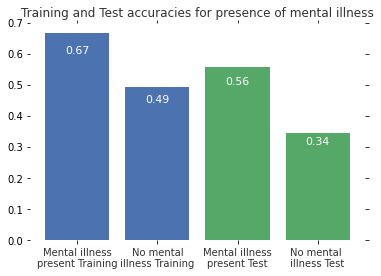

In [32]:
def accuracy_plot(knn):

#     %matplotlib notebook

    # Find the training and testing accuracies by target value (i.e. malignant, benign)
    mal_train_X = X_train[y_train==0]
    mal_train_y = y_train[y_train==0]
    ben_train_X = X_train[y_train==1]
    ben_train_y = y_train[y_train==1]

    mal_test_X = X_test[y_test==0]
    mal_test_y = y_test[y_test==0]
    ben_test_X = X_test[y_test==1]
    ben_test_y = y_test[y_test==1]

    scores = [knn.score(mal_train_X, mal_train_y), knn.score(ben_train_X, ben_train_y), 
              knn.score(mal_test_X, mal_test_y), knn.score(ben_test_X, ben_test_y)]


    plt.figure()

    # Plot the scores as a bar chart
    bars = plt.bar(np.arange(4), scores, color=['#4c72b0','#4c72b0','#55a868','#55a868'])

    # directly label the score onto the bars
    for bar in bars:
        height = bar.get_height()
        plt.gca().text(bar.get_x() + bar.get_width()/2, height*.90, '{0:.{1}f}'.format(height, 2), 
                     ha='center', color='w', fontsize=11)

    # remove all the ticks (both axes), and tick labels on the Y axis
    plt.tick_params(top='off', bottom='off', left='off', right='off', labelleft='off', labelbottom='on')

    # remove the frame of the chart
    for spine in plt.gca().spines.values():
        spine.set_visible(False)

    plt.xticks([0,1,2,3], ['Mental illness\npresent Training', 'No mental\nillness Training', 'Mental illness\npresent Test', 'No mental \nillness Test'], alpha=0.8);
    plt.title('Training and Test accuracies for presence of mental illness', alpha=0.8)

accuracy_plot(knn)

#### CIT / Police Violence 

In [33]:
# PVsample['Year'] = pd.DatetimeIndex(PVsample['Date of Incident (month/day/year)']).year
PVsample['Charges'] = np.where(PVsample['Criminal Charges?'].str.contains('Charged'),1,0)
PVsample['Armed']= np.where(PVsample['Armed/Unarmed Status'].str.contains('Unarmed|Unclear'),0,1)
PVsample['Mental illness'] = np.where(PVsample['Symptoms of mental illness?'].str.contains('Yes'),1,0)
PVsampleCounts = pd.DataFrame(PVsample.groupby(['period',"Victim's race",'Mental illness','Charges','Armed'])['Cause of death'].count())
PVsampleCounts = PVsampleCounts.rename(columns={"Cause of death":'Death_count'})
PVsampleCounts = PVsampleCounts.reset_index()
PVsampleCounts = PVsampleCounts.rename(columns={"Victim's race":"Race"})
PVsampleCounts['Black'] = np.where(PVsampleCounts['Race']=='Black',1,0)
PVsampleCounts['White'] = np.where(PVsampleCounts['Race']=='White',1,0)
PVsampleCounts['Hispanic'] = np.where(PVsampleCounts['Race']=='Hispanic',1,0)
PVsampleCounts['Unknown_race'] = np.where(PVsampleCounts['Race']=='Unknown race',1,0)
PVsampleCounts['CIT'] = np.where((PVsampleCounts['period']>=3),1,0)


preCITperiod = PVsampleCounts[PVsampleCounts['CIT']==0]
CITperiod = PVsampleCounts[PVsampleCounts['CIT']==1]

feature_names = ['CIT', 'Mental illness', 'Charges', 'Armed','Black'] #add in population
x_vals = ['Mental illness', 'Charges', 'Armed','Black']

In [34]:
#train-test-split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(PVsampleCounts[x_vals], PVsampleCounts['CIT'], test_size=0.33, random_state=42)

In [35]:
#knn training
from sklearn.neighbors import KNeighborsClassifier
knnCIT = KNeighborsClassifier(n_neighbors = 1)
knnCIT.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [36]:
#prediction on mean value
prediction = knnCIT.predict(X_train).reshape(-1,1)
unique, counts = np.unique(prediction, return_counts=True)
avgdata = dict(zip(unique, counts))
values = avgdata.values()
morecommon = max(values)
keys = avgdata.keys()
def get_key(val): 
    for key, value in avgdata.items(): 
         if val == value: 
            return key 
commonkey  = get_key(morecommon)
pred = np.unique(prediction)

filterpred = pred == commonkey
pred = pred[filterpred]
pred

array([0])

In [37]:
#prediction on test set
preds = knnCIT.predict(X_test)

In [38]:
#evaluation on test set
knnCIT = KNeighborsClassifier(n_neighbors = 1)
knnCIT.fit(X_train, y_train)
score = knnCIT.score(X_test, y_test)

In [39]:
#model parameter tuning
def optimal_k():
    k_best = None
    
    
    k_range = range(1,21,2)
    scores = []
        
    for k in k_range:
        knnCIT = KNeighborsClassifier(n_neighbors = k)
        knnCIT.fit(X_train, y_train)
        scores.append([k,knn.score(X_test, y_test)])
        
    maxscore = 0
    k_best = 0
    
    for score in scores:
        if score[1]>maxscore:
            maxscore = score[1]
            k_best = score[0]
        else:
            next
    
    display(scores)
    
    return k_best

optimal_k()

[[1, 0.52],
 [3, 0.52],
 [5, 0.52],
 [7, 0.52],
 [9, 0.52],
 [11, 0.52],
 [13, 0.52],
 [15, 0.52],
 [17, 0.52],
 [19, 0.52]]

1

In [40]:
#testing for overfitting
def overfitting(knn):
    k_best = None    
    training_score = None
    test_score = None
#     knn = None
    
#     X_train, X_test, y_train, y_test = train_test_split(policeViolenceCounts[x_vals], policeViolenceCounts['Mental illness'], test_size=0.33, random_state=42)
    
    knn = KNeighborsClassifier(n_neighbors = optimal_k())
    knn.fit(X_train, y_train)
    training_score = knn.score(X_train, y_train)
    test_score = knn.score(X_test, y_test)
    
#     X_train, X_test, y_train, y_test = answer_four()
    
    k_range = range(1,21,2)
    scores = []
        
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors = k)
        knn.fit(X_train, y_train)
        scores.append([k,knn.score(X_train, y_train)])
        
    maxscore = 0
    train_best = 0
    
    for score in scores:
        if score[1]>maxscore:
            maxscore = score[1]
            train_best = score[0]
        else:
            next
    
    knn1 = KNeighborsClassifier(n_neighbors = train_best)
    knn1.fit(X_test, y_test)
    test_score = knn1.score(X_test, y_test)
    
    k_best = (train_best, maxscore, test_score)
    
    return k_best

overfitting(knnCIT)

[[1, 0.52],
 [3, 0.52],
 [5, 0.52],
 [7, 0.52],
 [9, 0.52],
 [11, 0.52],
 [13, 0.52],
 [15, 0.52],
 [17, 0.52],
 [19, 0.52]]

(7, 0.66, 0.56)

### Visualization

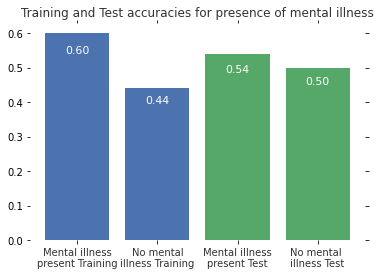

In [41]:
accuracy_plot(knnCIT)

### Analysis

## Logistic regression

### Model development

In [42]:
#LOGISTIC REGRESSION 1 police violence dataset With Criminal Charges as Target Variable##
########################
pd.set_option('display.max_columns', 50)

policeViolence_copy = policeViolence

policeViolence_copy['Year'] = pd.DatetimeIndex(policeViolence['Date of Incident (month/day/year)']).year
policeViolence_copy = pd.DataFrame(policeViolence_copy.groupby(['Year',"Victim's race",'Criminal Charges?','Armed/Unarmed Status','Alleged Threat Level (Source: WaPo)','Cause of death'])['Cause of death'].count())
# dallas['RIGHT'] = np.where((dallas['Year']>=2018),1,0)
# dallasCounts = pd.DataFrame(dallas.groupby(['RIGHT',"Victim's race"])["Victim's race"].count())
policeViolence_copy = policeViolence_copy.rename(columns={"Cause of death":'Death_count'})
policeViolence_copy = policeViolence_copy.reset_index()
policeViolence_copy = policeViolence_copy.rename(columns={"Victim's race":"Race"})
policeViolence_copy = policeViolence_copy.rename(columns={"Criminal Charges?":'Criminal_Charges'})
policeViolence_copy = policeViolence_copy.rename(columns={"Armed/Unarmed Status":'Armed_Status'})
policeViolence_copy = policeViolence_copy.rename(columns={"Alleged Threat Level (Source: WaPo)":'Alleged_Threat_Level'})
policeViolence_copy['Charges'] = np.where(policeViolence_copy['Criminal_Charges'].str.contains('Charged'),1,0)
policeViolence_copy['RIGHT'] = np.where((policeViolence_copy['Year']>=2018),1,0)
policeViolence_copy['Black'] = np.where(policeViolence_copy['Race']=='Black',1,0)
policeViolence_copy['White'] = np.where(policeViolence_copy['Race']=='White',1,0)
policeViolence_copy['Hispanic'] = np.where(policeViolence_copy['Race']=='Hispanic',1,0)
policeViolence_copy['Unknown_race'] = np.where(policeViolence_copy['Race']=='Unknown race',1,0)

logreg_1_policeViolence = smf.logit(formula='Charges ~ RIGHT + Black + White + Hispanic + Unknown_race', data=policeViolence_copy).fit()


covariates_policeViolence_logreg1 = ['Intercept','RIGHT','Black','White','Hispanic','Unknown_race']
policeViolence_logreg_table = Stargazer([logreg_1_policeViolence])
policeViolence_logreg_table.covariate_order(covariates_policeViolence_logreg1)
policeViolence_logreg_table

         Current function value: 0.332756
         Iterations: 35


/opt/oss/conda3/lib/python3.7/site-packages/statsmodels/base/model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


### Visualization

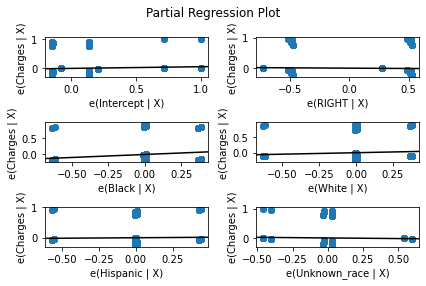

In [43]:
fig = sm.graphics.plot_partregress_grid(logreg_1_policeViolence)
fig.tight_layout(pad=1.0)

### Analysis

The small multiples regression plot above provides a granular view of how each independent variable's relationship(RIGHT, Black, White, Hispanic, Unknown_race) with the target variable 'charges.' It is evident from a visual standpoint that the majority of the predictor variables do not have a strong relationship with the target variable, which is evident by their large p-values. Specifically, the variables RIGHT, HISPANIC, and UNKNOWN_race are not statistically significant even at an alpha of 0.10, which implies that the null hypothesis - i.e. that the each of these predictor variables have an individual relationship with the target variable - cannot be rejected in favor of the null hypothesis, which states that some form of relationship, be it positive or negative, esists between them. The only two variables that have a visually salient relationship with the target would be the predictor variables White and Black. Both are significant even at an alpha of 0.01, which implies that there's only a 1% chance that we have incorrectly rejected the null hypothesis, and furthermore implies that the p-values for these two variables are less than 1%. It is worth noting that the p-values does not imply any information regarding the size or magnitude of the difference observed. In our case, it simply implies that, if we were to repeat this experiment multiple times with new samples, we would only see a difference as large or larger than the ones we have observed under 1% of the time. 

In regards to the coefficients, as we are considering binary logistic regression for this analysis, what they mean differs from OLS regression. As we are considering binary categorical predictors, the reference level would be 0 for each of them. The coefficients for the variables RIGHT and Unknown_race are negative, which means the event in question(charges) is less likely to occur at the predictor level - in other words, when these variables equal one - than at the reference level. Conversely, for the predictors Black, White, and Hispanic, the coefficients are positive, which tells us that the event in question(charges) is more likely to occur at the predictor level(when they equal 1) than at the reference level. Furthermore, all of the coefficients in this scenario represent the change in the natural log odds of the event occuring when going from the reference level to the predictor level, with the sign simply indicating the directionality of that change. Taking the predictor Black as an example, a coefficient of 1.8 implies that the natural log odds of the event 'charges' occuring increases by 1.8% whenever Black is equal to 1.

### Model Development

In [70]:
#LOGISTIC REGRESSION 2 PVsample dataset With Mental illness as Target Variable##
########################
pd.set_option('display.max_columns', 50)


PVsample_copy = PVsample

PVsample_copy["Victim's race"].unique()

PVsample_copy.head()

PVsample_copy['Gender_Binary'] = np.where(PVsample_copy["Victim's gender"]=='Male',1,0)

PVsample_copy['Race_Black'] = np.where(PVsample_copy["Victim's race"]=='Black',1,0)

PVsample_copy['Race_Hispanic'] = np.where(PVsample_copy["Victim's race"]=='Hispanic',1,0)

PVsample_copy['Race_White'] = np.where(PVsample_copy["Victim's race"]=='White',1,0)

PVsample_copy['Race_Pacific_Islander'] = np.where(PVsample_copy["Victim's race"]=='Pacific Islander',1,0)

PVsample_copy['Race_Asian'] = np.where(PVsample_copy["Victim's race"]=='Asian',1,0)

PVsample_copy['Race_Native_American'] = np.where(PVsample_copy["Victim's race"]=='Native American',1,0)

PVsample_copy = PVsample_copy.rename(columns={"Mental illness": "Mental_illness"})


PVsample_copy["Victim's race"].unique()

logreg_2_PVsample = smf.logit(formula='Mental_illness ~ Charges + Armed + Gender_Binary + Race_Black + Race_Hispanic + Race_White + Race_Pacific_Islander + Race_Asian + Race_Native_American', data=PVsample_copy).fit()



covariates_PVsample_logreg2 = ['Intercept','Charges','Armed','Gender_Binary','Race_Black', 'Race_White', 'Race_Pacific_Islander', 'Race_Asian', 'Race_Native_American']
PVsample_logreg2_table = Stargazer([logreg_2_PVsample])
PVsample_logreg2_table.covariate_order(covariates_PVsample_logreg2)
PVsample_logreg2_table


         Current function value: 0.490002
         Iterations: 35


/opt/oss/conda3/lib/python3.7/site-packages/statsmodels/base/model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


### Visualization

### Analysis

## Linear regression

### Model development

### Visualization

### Analysis

## OLS regression

### Model development

In [44]:
#RACE NORMALIZATION

olympia1819offenses = wash1819offenses[wash1819offenses['COUNTY_NAME']=='THURSTON']
olympia1819offenses['INCIDENT_YEAR'] = pd.DatetimeIndex(olympia1819offenses['INCIDENT_DATE']).year
olympia1819offenseCounts = pd.DataFrame(olympia1819offenses.groupby(['INCIDENT_YEAR','INCIDENT_MONTH','RACE_DESC'])['OFFENSE_NAME'].count())
olympia1819offenseCounts = olympia1819offenseCounts.rename(columns={'OFFENSE_NAME':'OFFENSE_COUNT'})
olympia1819offenseCounts = olympia1819offenseCounts.reset_index()
olympia1819offenseCounts['CRU'] = np.where((olympia1819offenseCounts['INCIDENT_MONTH']<4)|(olympia1819offenseCounts['INCIDENT_YEAR']==2018),0,1)
relevant_offenses = ['Trespass of Real Property','Curfew/Loitering/Vagrancy Violations','Drug/Narcotic Violations','Drug Equipment Violations','Drunkenness','Disorderly Conduct','Family Offenses, Nonviolent']
olympia1819offenseCounts = olympia1819offenseCounts[olympia1819offenseCounts.RACE_DESC != 'Unknown']
olympia1819offenseCountsRace = olympia1819offenseCounts[olympia1819offenseCounts['OFFENSE_COUNT'].isin(relevant_offenses)]


#Pull in CENSUS data
race_descriptions = olympia1819offenseCounts['RACE_DESC'].unique()
census_data_olympia = pd.read_csv('QuickFacts Aug-25-2021.csv')
race_descriptions_dict = {"White":75.9, "American Indian or Alaska Native":1.0, "Asian":7.1, "Black or African American": 2.6}

#Normalize Offense Rate
twenty_eighteen_total = olympia1819offenseCounts.groupby('INCIDENT_YEAR')['OFFENSE_COUNT'].sum()[2018]
twenty_nineteen_total = olympia1819offenseCounts.groupby('INCIDENT_YEAR')['OFFENSE_COUNT'].sum()[2019]
olympia1819offenseCounts['TOTAL_OFFENSES_PER_YEAR'] = np.where(olympia1819offenseCounts['INCIDENT_YEAR']==2018, twenty_eighteen_total, twenty_nineteen_total)
olympia1819offenseCounts['PCT_OF_POPULATION'] = olympia1819offenseCounts['RACE_DESC'].map(race_descriptions_dict)
olympia1819offenseCounts['WEIGHTED OFFENSE RATE'] = (100-olympia1819offenseCounts['PCT_OF_POPULATION']) * olympia1819offenseCounts['OFFENSE_COUNT']
olympia1819offenseCounts

/opt/oss/conda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


,INCIDENT_YEAR,INCIDENT_MONTH,RACE_DESC,OFFENSE_COUNT,CRU,TOTAL_OFFENSES_PER_YEAR,PCT_OF_POPULATION,WEIGHTED OFFENSE RATE
0,2018,1,American Indian or Alaska Native,9,0,6027,1.0,891.0
1,2018,1,Asian,16,0,6027,7.1,1486.4
2,2018,1,Black or African American,43,0,6027,2.6,4188.2
4,2018,1,White,417,0,6027,75.9,10049.7
5,2018,2,American Indian or Alaska Native,14,0,6027,1.0,1386.0
6,2018,2,Asian,19,0,6027,7.1,1765.1
7,2018,2,Black or African American,41,0,6027,2.6,3993.4
9,2018,2,White,384,0,6027,75.9,9254.4
10,2018,3,American Indian or Alaska Native,4,0,6027,1.0,396.0
11,2018,3,Asian,14,0,6027,7.1,1300.6


In [45]:
#################################################################################################################################################

In [46]:
#####################
####Grouping data####
olympia1819offenses = wash1819offenses[wash1819offenses['COUNTY_NAME']=='THURSTON']
olympia1819offenses['INCIDENT_YEAR'] = pd.DatetimeIndex(olympia1819offenses['INCIDENT_DATE']).year
olympia1819offenseCounts = pd.DataFrame(olympia1819offenses.groupby(['INCIDENT_YEAR','INCIDENT_MONTH','RACE_DESC','OFFENSE_NAME'])['OFFENSE_NAME'].count())
olympia1819offenseCounts = olympia1819offenseCounts.rename(columns={'OFFENSE_NAME':'OFFENSE_COUNT'})
olympia1819offenseCounts = olympia1819offenseCounts.reset_index()
olympia1819offenseCounts['CRU'] = np.where((olympia1819offenseCounts['INCIDENT_MONTH']<4)|(olympia1819offenseCounts['INCIDENT_YEAR']==2018),0,1)
relevant_offenses = ['Trespass of Real Property','Curfew/Loitering/Vagrancy Violations','Drug/Narcotic Violations','Drug Equipment Violations','Drunkenness','Disorderly Conduct','Family Offenses, Nonviolent']
olympia1819offenseCountsRace = olympia1819offenseCounts[olympia1819offenseCounts['OFFENSE_NAME'].isin(relevant_offenses)]

modelA = smf.ols(formula='OFFENSE_COUNT ~ CRU', data=olympia1819offenseCountsRace).fit()
modelB = smf.ols(formula='OFFENSE_COUNT ~ CRU + RACE_DESC', data=olympia1819offenseCountsRace).fit()

olympia1819offenses = wash1819offenses[wash1819offenses['COUNTY_NAME']=='THURSTON']
olympia1819offenses['INCIDENT_YEAR'] = pd.DatetimeIndex(olympia1819offenses['INCIDENT_DATE']).year
olympia1819offenseCounts = pd.DataFrame(olympia1819offenses.groupby(['INCIDENT_YEAR','INCIDENT_MONTH','RACE_DESC','LOCATION_NAME','OFFENSE_NAME'])['OFFENSE_NAME'].count())
olympia1819offenseCounts = olympia1819offenseCounts.rename(columns={'OFFENSE_NAME':'OFFENSE_COUNT'})
olympia1819offenseCounts = olympia1819offenseCounts.reset_index()
olympia1819offenseCounts['CRU'] = np.where((olympia1819offenseCounts['INCIDENT_MONTH']<4)|(olympia1819offenseCounts['INCIDENT_YEAR']==2018),0,1)
relevant_offenses = ['Trespass of Real Property','Curfew/Loitering/Vagrancy Violations','Drug/Narcotic Violations','Drug Equipment Violations','Drunkenness','Disorderly Conduct','Family Offenses, Nonviolent']
olympia1819offenseCounts = olympia1819offenseCounts[olympia1819offenseCounts['OFFENSE_NAME'].isin(relevant_offenses)]

modelC = smf.ols(formula='OFFENSE_COUNT ~ CRU + RACE_DESC + LOCATION_NAME', data=olympia1819offenseCounts).fit()

### Example code ####

#`smf.ols(formula="y ~ treatment + x1 + x2 ...")#
#"fixed effect for var_x", you can add a `+C(var_x)`

#OFFENSE OLS REGRESSION#
########################
covariates = ['Intercept','CRU','RACE_DESC','LOCATION_NAME']
Q3_table = Stargazer([modelA,modelB,modelC])
# Q3_table.covariate_order(covariates)
Q3_table
#######################
#######################

/opt/oss/conda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
/opt/oss/conda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app.launch_new_instance()


In [47]:
#VICTIM OLS REGRESSION##
########################
pd.set_option('display.max_columns', 50)
# justForce = olympia1819offenses[olympia1819offenses['CIRCUMSTANCES_CODE']=='21']
# olympia1819offenses

dallas['Year'] = pd.DatetimeIndex(dallas['Date of Incident (month/day/year)']).year
dallasCounts = pd.DataFrame(dallas.groupby(['Year',"Victim's race",'Criminal Charges?','Armed/Unarmed Status','Alleged Threat Level (Source: WaPo)','Cause of death'])['Cause of death'].count())
# dallas['RIGHT'] = np.where((dallas['Year']>=2018),1,0)
# dallasCounts = pd.DataFrame(dallas.groupby(['RIGHT',"Victim's race"])["Victim's race"].count())
dallasCounts = dallasCounts.rename(columns={"Cause of death":'Death_count'})
dallasCounts = dallasCounts.reset_index()
dallasCounts = dallasCounts.rename(columns={"Victim's race":"Race"})
dallasCounts = dallasCounts.rename(columns={"Criminal Charges?":'Criminal_Charges'})
dallasCounts = dallasCounts.rename(columns={"Armed/Unarmed Status":'Armed_Status'})
dallasCounts = dallasCounts.rename(columns={"Alleged Threat Level (Source: WaPo)":'Alleged_Threat_Level'})
dallasCounts['RIGHT'] = np.where((dallasCounts['Year']>=2018),1,0)
dallasCounts['Black'] = np.where(dallasCounts['Race']=='Black',1,0)
dallasCounts['White'] = np.where(dallasCounts['Race']=='White',1,0)
dallasCounts['Hispanic'] = np.where(dallasCounts['Race']=='Hispanic',1,0)
dallasCounts['Unknown_race'] = np.where(dallasCounts['Race']=='Unknown race',1,0)


# modelA = smf.ols(formula="Death_count ~ RIGHT + Race + Criminal_Charges + Armed_Status + Alleged_Threat_Level", data=dallasCounts).fit()
modelA = smf.ols(formula="Death_count ~ Black + White + Hispanic + Unknown_race", data=dallasCounts).fit()
modelB = smf.ols(formula="Death_count ~ RIGHT + Black + White + Hispanic + Unknown_race", data=dallasCounts).fit()
covariates = ['Intercept','RIGHT','Black','White','Hispanic','Unknown_race']
dallas_table = Stargazer([modelA,modelB])
dallas_table.covariate_order(covariates)
dallas_table


########################
########################

In [48]:
PVsampleCounts = pd.DataFrame(PVsample.groupby(['period',"Victim's race",'Criminal Charges?','Armed/Unarmed Status','Alleged Threat Level (Source: WaPo)','Cause of death'])['Cause of death'].count())
# PVsample['RIGHT'] = np.where((PVsample['Year']>=2018),1,0)
# PVsampleCounts = pd.DataFrame(PVsample.groupby(['RIGHT',"Victim's race"])["Victim's race"].count())
PVsampleCounts = PVsampleCounts.rename(columns={"Cause of death":'Death_count'})
PVsampleCounts = PVsampleCounts.reset_index()
PVsampleCounts = PVsampleCounts.rename(columns={"Victim's race":"Race"})
PVsampleCounts = PVsampleCounts.rename(columns={"Criminal Charges?":'Criminal_Charges'})
PVsampleCounts = PVsampleCounts.rename(columns={"Armed/Unarmed Status":'Armed_Status'})
PVsampleCounts = PVsampleCounts.rename(columns={"Alleged Threat Level (Source: WaPo)":'Alleged_Threat_Level'})
PVsampleCounts['CIT'] = np.where((PVsampleCounts['period']>=3),1,0)
PVsampleCounts['Black'] = np.where(PVsampleCounts['Race']=='Black',1,0)
PVsampleCounts['White'] = np.where(PVsampleCounts['Race']=='White',1,0)
PVsampleCounts['Hispanic'] = np.where(PVsampleCounts['Race']=='Hispanic',1,0)
PVsampleCounts['Unknown_race'] = np.where(PVsampleCounts['Race']=='Unknown race',1,0)


# modelA = smf.ols(formula="Death_count ~ RIGHT + Race + Criminal_Charges + Armed_Status + Alleged_Threat_Level", data=PVsampleCounts).fit()
modelA = smf.ols(formula="Death_count ~ Black + White + Hispanic + Unknown_race", data=PVsampleCounts).fit()
modelB = smf.ols(formula="Death_count ~ CIT + Black + White + Hispanic + Unknown_race", data=PVsampleCounts).fit()
covariates = ['Intercept','CIT','Black','White','Hispanic','Unknown_race']
PVsample_table = Stargazer([modelA,modelB])
PVsample_table.covariate_order(covariates)
PVsample_table

### Visualization

### Analysis

# Unsupervised models

## PCA

### Model development

#### Police violence

In [49]:
feature_names = ['Year', 'Mental illness', 'Charges', 'Armed','Black'] #add in population
x_vals = ['Year', 'Charges', 'Armed', 'Black']
PV = policeViolenceCounts[feature_names]
pcaDf = pd.DataFrame(StandardScaler().fit(PV).transform(PV))
# PV

In [50]:
comp_lst = []
exp_var = []
for x in range(1,6):
    pca = PCA(n_components = x,random_state=42).fit(pcaDf)
    comp_lst.append(x)
    exp_var.append(list(pca.explained_variance_))
dict(zip(comp_lst,exp_var))
comps = pd.DataFrame.from_dict(dict(zip(comp_lst,exp_var[4])),orient='index')
comps.reset_index(inplace=True)
comps.columns=['component','vals']
comps

alt.Chart(comps).mark_circle(size=100,color='#696969').encode(
    alt.X('component',axis=alt.Axis(tickCount=len(comp_lst)+1,grid=False),scale=alt.Scale(domain=[0,6])),
    alt.Y('vals',axis=alt.Axis(grid=False),scale=alt.Scale(domain=[0.8,1.6])))

NameError: name 'PCA' is not defined

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2,random_state=42).fit(pcaDf)

In [ ]:
#Explained variance
explained_variance = pca.explained_variance_
display(explained_variance)

### Visualization

In [ ]:
def plot_pca_heatmap(pca, feature_names):
    pc_names = ['First PC', 'Second PC']#, 'Third PC']
    fig, ax = plt.subplots(figsize=(8, 2))
    plt.imshow(pca.components_, interpolation = 'none', cmap = 'inferno')
    feature_names=list(feature_names)
    plt.xticks(np.arange(-0.5, 5, 1) , feature_names, rotation = 75, fontsize=16)
    plt.yticks(np.arange(0.0, 2, 1), pc_names, fontsize = 16)
    plt.colorbar()

plot_pca_heatmap(pca, feature_names)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
def biplot(score, coeff, maxdim, pcax, pcay, labels=None):
    pca1=pcax-1
    pca2=pcay-1
    xs = score[:,pca1]
    ys = score[:,pca2]
    n = min(coeff.shape[0], maxdim)
    scalex = 2.0/(xs.max()- xs.min())
    scaley = 2.0/(ys.max()- ys.min())
    text_scale_factor = 1.5
    plt.scatter(xs*scalex, ys*scaley, s=1)
    for i in range(n):
        plt.arrow(0, 0, coeff[i,pca1], coeff[i,pca2],color='r',alpha=0.5) 
        if labels is None:
            plt.text(coeff[i,pca1]* text_scale_factor, coeff[i,pca2] * text_scale_factor, "Var"+str(i+1), color='g', ha='center', va='center')
        else:
            plt.text(coeff[i,pca1]* text_scale_factor, coeff[i,pca2], labels[i], color='g', ha='center', va='center')
    plt.xlim(-1,1)
    plt.ylim(-1,1)
    plt.xlabel("PC{}".format(pcax))
    plt.ylabel("PC{}".format(pcay))
    plt.grid()

plt.figure()

PVpca = pca.transform(pcaDf)
biplot(PVpca, np.transpose(pca.components_[0:2, :]), 8, 1, 2, labels=feature_names)

#### Determining how many components to use

In [ ]:
from sklearn.decomposition import PCA
comp_lst = []
vars_lst = []
for x in range(6):
    pca = PCA(n_components = x,random_state=42).fit(pcaDf)
    comp_lst.append(x)
#variance of pca components
    pca_vars = []
    for x in range(len(pca.components_)):
        pca_vars.append(np.std(pca.components_[x]))

#proportion of variance explained
        prop_varex = []
        for pca_var in pca_vars:
            prop_varex.append(pca_var/sum(pca_vars))
        vars_lst.append(prop_varex)
dict(zip(comp_lst,vars_lst))

### Analysis

We decided to utilize PCA in conjunction with a biplot as a data exploration technique in order to facilitate easy assessment of the relationship between the predictor variables while minimizing information loss, while also affording us insight as to which features capture the greatest variance within the dataset. For the purposes of this analysis and ease of interpretability, we decided to project two principal components on a two-dimensional plot, and also made the assumption that these two principal components reprsent at least 80% of the variance within the data. Each data point on the biplot represents an individual datapoint from the original dataset projected onto this two=dimensional space, while each vector is a variable marker representing the loadings for each column in the dataset. Visually speaking, the biplot is fairly insightful. Considering that one of the properties of PCA is that the consine of the angle between any two variable markers is the coefficient of correlation between those variables - in other words, the smaller the angle, the more correlated the variables are - we can conclude that the variables Armed and Death_count are at least somewhat correlated. From an intuition standpoint, this makes sense, as police responses are more likely to result in fatalities if the assailant is armed. Conversely, the variables Mental illness and Charges don't appear to be correlated with any ony other vector marker. However, the variable Mental illness does have a bearing on the first principle component, as the angle between that vector and the axis between the first principal component is small, which implies that when that variable is large, PC1 is large as well. Furthermore, Armed has quite a bit of bearing on the second principal component, since the angle between that vector and the axis for PC2 is small. 

#### CIT / police violence

In [ ]:
# feature_names = ['CIT', 'Mental illness', 'Charges', 'Armed','Black'] #add in population
# x_vals = ['Mental illness', 'Charges', 'Armed','Black']
# PV = PVsampleCounts[feature_names]
# pcaDf = pd.DataFrame(StandardScaler().fit(PV).transform(PV))
PVsampleCounts

## DBSCAN

### Model development

In [ ]:
policeViolence_copy_DBSCAN = policeViolence_copy
policeViolence_copy_DBSCAN

### Visualization

### Analysis

## API

In [ ]:
### API call library ###
########################

# https://crime-data-explorer.fr.cloud.gov/pages/docApi

########################
########################


In [ ]:
url = "https://api.usa.gov/crime/fbi/sapi/api/agencies/list?api_key=" + apikey
headers = {'Accept': 'application/json'}

response = requests.get(url, headers=headers)

data = json.loads(response.content)
agencies = pd.DataFrame(data)
oris = list(agencies['ori'].unique())

In [ ]:
#summarized-data-controller#
#second one - Agency level SRS crime data endpoint#
offenses = []
# for ori in tqdm(oris[:100]):
for ori in oris[:100]:
    try:
        url = f"https://api.usa.gov/crime/fbi/sapi/api/summarized/agencies/{ori}/offenses/2019/2021?api_key=" + apikey
        
        headers = {'Accept': 'application/json'}

        response = requests.get(url, headers=headers)

        data = json.loads(response.content)
        offenses.append(pd.DataFrame(data['results']))
    except:
        pass
    
offensesDf = pd.concat(offenses)
display(offensesDf)

In [ ]:
url = f"https://api.usa.gov/crime/fbi/sapi/api/summarized/agencies/CODPD0000/offenses/2016/2018?api_key=" + apikey

headers = {'Accept': 'application/json'}

response = requests.get(url, headers=headers)

data = json.loads(response.content)
# pd.DataFrame(data['results'])

In [ ]:
#arrest-tkm-controller
offensesDemo = []
KC = 'MOKPD0000'
for ori in oris[:100]:
    try:
        url = f"https://api.usa.gov/crime/fbi/sapi/api/arrest/agencies/offense/{ori}/all/2018/2020?api_key=" + apikey
#         url = f"https://api.usa.gov/crime/fbi/sapi/api/arrest/agencies/offense/{KC}/drug/2019/2021?api_key=" + apikey
        headers = {'Accept': 'application/json'}

        response = requests.get(url, headers=headers)

        data = json.loads(response.content)
        display(data)
#         offensesDemo.append(pd.DataFrame(data['results']))
    except:
        pass
    
# offensesDemoDf = pd.concat(offensesDemo)

# url = f"https://api.usa.gov/crime/fbi/sapi/api/arrest/agencies/offense/{KC}/drug/2019/2021?api_key=" + apikey
# headers = {'Accept': 'application/json'}

# response = requests.get(url, headers=headers)

# data = json.loads(response.content)
# display(data)

# url = f"https://api.usa.gov/crime/fbi/sapi/api/arrest/agencies/{KC}/drug-grand-total/race/2019/2021?api_key=" + apikey
# headers = {'Accept': 'application/json'}

# response = requests.get(url, headers=headers)

# data = json.loads(response.content)
# display(data)

In [ ]:
agencies = requests.get('https://api.usa.gov/crime/fbi/sapi/api/nibrs/property-crime',auth=('key',apikey))
data = json.loads(agencies.content)
# pd.DataFrame(data)
data